# JAEE — Table IV, V, VI dan Fig. 5: Klasifikasi risiko stroke (XGBoost berbobot kelas)

Menghasilkan **Fig. 5** (kepentingan fitur, kurva PR, analisis ambang), **Table IV** (diskriminasi, pembobotan kelas vs. pembanding), **Table V** (titik operasi pada ambang target recall) dan **Table VI** (sensitivitas terhadap galat estimasi PPG).

Prasyarat: jalankan `jaee_2_estimasi_vital_loso.ipynb` DULU (Table VI memakai `hasil_estimasi.json`). Split data dan model identik dengan `model/train.py`; sel pertama memverifikasi AUC yang direproduksi sama dengan yang tersimpan di artefak.

In [1]:
import warnings, sys, json, pathlib
warnings.simplefilter("ignore")
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Semua gambar/JSON artikel JAEE disimpan di sini (relatif terhadap folder model/)
FIG = pathlib.Path("../figures-jaee")
FIG.mkdir(exist_ok=True)

# Gaya sesuai template JAEE: Times New Roman 8 pt, kolom 3,5 in / halaman 7,16 in, 300 dpi
plt.rcParams.update({
    "font.family": "serif", "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 8, "legend.fontsize": 7,
    "xtick.labelsize": 7, "ytick.labelsize": 7, "figure.dpi": 110, "savefig.dpi": 300,
    "axes.grid": True, "grid.alpha": .25, "axes.spines.top": False, "axes.spines.right": False,
    "mathtext.fontset": "stix",
})
COL_W, PAGE_W = 3.5, 7.16

def save(fig, name):
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight")
    fig.savefig(FIG / f"{name}.pdf", bbox_inches="tight")


In [2]:
import joblib
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, precision_recall_curve, roc_auc_score
from sklearn.model_selection import cross_val_predict, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

from model.train import (BINARY_FEATURES, CATEGORICAL_FEATURES, CV, FEATURE_ORDER, NUMERIC_FEATURES,
                         RANDOM_STATE, TARGET_RECALL, _ordinal_encode_for_xgb, recall_target_threshold)
def J(o):
    if isinstance(o, np.floating): return float(o)
    if isinstance(o, np.integer): return int(o)
    if isinstance(o, np.ndarray): return o.tolist()
    return str(o)

art = joblib.load("artifacts/stroke_risk_model.joblib")
meta = art["metrics"]
TAU_DET, TAU_HIGH = float(art["threshold"]), float(art["high_threshold"])

from model.train import load_dataset
data = load_dataset()
X, y = data[FEATURE_ORDER], data["stroke"]
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y)
Xe_tr, Xe_te = _ordinal_encode_for_xgb(X_tr), _ordinal_encode_for_xgb(X_te)

p_te = art["model"].predict_proba(Xe_te)[:, 1]
print("AUC direproduksi:", round(roc_auc_score(y_te, p_te), 6), "| tersimpan:", round(meta["test_auc"], 6))
assert abs(roc_auc_score(y_te, p_te) - meta["test_auc"]) < 1e-6, "split/model tidak sama dengan artefak"

desc = dict(n=int(len(data)), n_pos=int(y.sum()), pos_rate=float(y.mean()), n_train=int(len(X_tr)), n_test=int(len(X_te)),
            n_pos_train=int(y_tr.sum()), n_pos_test=int(y_te.sum()), bmi_missing=int(data.bmi.isna().sum()),
            age_mean_pos=float(data.loc[y == 1, "age"].mean()), age_mean_neg=float(data.loc[y == 0, "age"].mean()),
            hyp_rate_pos=float(data.loc[y == 1, "hypertension"].mean()),
            hyp_rate_neg=float(data.loc[y == 0, "hypertension"].mean()),
            scale_pos_weight=float(art["model"].get_params()["scale_pos_weight"]),
            tau_det=TAU_DET, tau_high=TAU_HIGH, target_recall=TARGET_RECALL,
            best_params={k: v for k, v in meta["best_params"].items()})
print(json.dumps(desc, indent=2, default=J))

AUC direproduksi: 0.822963 | tersimpan: 0.822963
{
  "n": 5110,
  "n_pos": 249,
  "pos_rate": 0.0487279843444227,
  "n_train": 3577,
  "n_test": 1533,
  "n_pos_train": 174,
  "n_pos_test": 75,
  "bmi_missing": 201,
  "age_mean_pos": 67.72819277108434,
  "age_mean_neg": 41.971544949598844,
  "hyp_rate_pos": 0.26506024096385544,
  "hyp_rate_neg": 0.08887060275663444,
  "scale_pos_weight": 19.557471264367816,
  "tau_det": 0.041999999999999926,
  "tau_high": 0.705,
  "target_recall": 0.98,
  "best_params": {
    "subsample": 1.0,
    "scale_pos_weight": 19.557471264367816,
    "reg_lambda": 1.0,
    "n_estimators": 100,
    "min_child_weight": 5,
    "max_depth": 4,
    "learning_rate": 0.03,
    "colsample_bytree": 1.0
  }
}


In [3]:
# ---------- Titik operasi pada data uji (model yang berjalan) ----------
def conf(y_true, p, t):
    yp = (p >= t).astype(int); yt = np.asarray(y_true)
    tp = int(((yp == 1) & (yt == 1)).sum()); fp = int(((yp == 1) & (yt == 0)).sum())
    fn = int(((yp == 0) & (yt == 1)).sum()); tn = int(((yp == 0) & (yt == 0)).sum())
    prec = tp / max(tp + fp, 1); rec = tp / max(tp + fn, 1)
    return dict(t=float(t), tp=tp, fp=fp, fn=fn, tn=tn, precision=prec, recall=rec,
                specificity=tn / max(tn + fp, 1), f1=2 * prec * rec / max(prec + rec, 1e-12),
                alert_rate=(tp + fp) / len(yt))

ops = {"tau_det": conf(y_te, p_te, TAU_DET), "tau_high": conf(y_te, p_te, TAU_HIGH), "default_0.5": conf(y_te, p_te, 0.5)}
print(pd.DataFrame(ops).T.round(4))

# Tiga tingkat risiko: rendah (<tau_det), sedang, tinggi (>=tau_high) + laju kejadian stroke teramati per tingkat
tier = np.where(p_te < TAU_DET, 0, np.where(p_te < TAU_HIGH, 1, 2))
tiers = []
for k, name in enumerate(["Low", "Medium", "High"]):
    m = tier == k
    tiers.append(dict(tier=name, n=int(m.sum()), events=int(y_te.to_numpy()[m].sum()),
                      event_rate=float(y_te.to_numpy()[m].mean()) if m.sum() else float("nan")))
print(pd.DataFrame(tiers))
auc = float(roc_auc_score(y_te, p_te)); ap = float(average_precision_score(y_te, p_te))
print("AUC =", round(auc, 4), " AP =", round(ap, 4), " prevalensi =", round(float(y_te.mean()), 4))

                 t    tp     fp    fn      tn  precision  recall  specificity  \
tau_det      0.042  73.0  905.0   2.0   553.0     0.0746  0.9733       0.3793   
tau_high     0.705  37.0  143.0  38.0  1315.0     0.2056  0.4933       0.9019   
default_0.5  0.500  57.0  408.0  18.0  1050.0     0.1226  0.7600       0.7202   

                 f1  alert_rate  
tau_det      0.1387      0.6380  
tau_high     0.2902      0.1174  
default_0.5  0.2111      0.3033  
     tier    n  events  event_rate
0     Low  555       2    0.003604
1  Medium  798      36    0.045113
2    High  180      37    0.205556
AUC = 0.823  AP = 0.25  prevalensi = 0.0489


In [4]:
# ---------- TABLE IV dan V: pengaruh pembobotan kelas & pembanding ----------
params = art["model"].get_params()
def xgb(spw):
    return XGBClassifier(**{**params, "scale_pos_weight": spw})

pre = ColumnTransformer([
    ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), NUMERIC_FEATURES),
    ("bin", "passthrough", BINARY_FEATURES),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES)])
lr = Pipeline([("pre", pre), ("clf", LogisticRegression(class_weight="balanced", max_iter=2000))])
as_obj = lambda d: d.astype({c: "object" for c in CATEGORICAL_FEATURES})

cands = [("XGBoost, unweighted", xgb(1.0), Xe_tr, Xe_te),
         ("XGBoost, class-weighted (proposed)", xgb(params["scale_pos_weight"]), Xe_tr, Xe_te),
         ("Logistic regression, balanced", lr, as_obj(X_tr), as_obj(X_te))]
comp, curves = [], {}
for name, mdl, Xa, Xb in cands:
    oof = cross_val_predict(clone(mdl), Xa, y_tr, cv=CV, method="predict_proba")[:, 1]
    tau = recall_target_threshold(y_tr.to_numpy(), oof, TARGET_RECALL)
    fit = clone(mdl).fit(Xa, y_tr)
    p = fit.predict_proba(Xb)[:, 1]
    c05, ctau = conf(y_te, p, 0.5), conf(y_te, p, tau)
    comp.append(dict(model=name, auc=float(roc_auc_score(y_te, p)), ap=float(average_precision_score(y_te, p)),
                     recall_at_05=c05["recall"], precision_at_05=c05["precision"], tau_recall_target=float(tau),
                     recall_at_tau=ctau["recall"], precision_at_tau=ctau["precision"], fp_at_tau=ctau["fp"],
                     fn_at_tau=ctau["fn"], alert_rate_at_tau=ctau["alert_rate"]))
    curves[name] = p
allc = pd.DataFrame(comp)
# TABLE IV: diskriminasi + titik operasi bawaan (0.5) | TABLE V: titik operasi pada ambang target recall
tab4 = allc[["model", "auc", "ap", "recall_at_05", "precision_at_05"]]
tab5 = allc[["model", "tau_recall_target", "recall_at_tau", "precision_at_tau", "fp_at_tau", "fn_at_tau", "alert_rate_at_tau"]]
print("TABLE IV"); print(tab4.round(3).to_string(index=False))
print("TABLE V"); print(tab5.round(3).to_string(index=False))

TABLE IV
                             model   auc    ap  recall_at_05  precision_at_05
               XGBoost, unweighted 0.838 0.271         0.013            1.000
XGBoost, class-weighted (proposed) 0.823 0.250         0.760            0.123
     Logistic regression, balanced 0.838 0.218         0.773            0.128
TABLE V
                             model  tau_recall_target  recall_at_tau  precision_at_tau  fp_at_tau  fn_at_tau  alert_rate_at_tau
               XGBoost, unweighted              0.010          0.933             0.082        786          5              0.558
XGBoost, class-weighted (proposed)              0.042          0.973             0.075        905          2              0.638
     Logistic regression, balanced              0.164          0.933             0.082        785          5              0.558


In [5]:
# ---------- TABLE VI: sensitivitas terhadap galat estimasi fisiologis (end-to-end) ----------
# Di lapangan dua masukan model stroke berasal dari estimasi PPG: kadar glukosa dan flag hipertensi
# (dari SBP/DBP). Galatnya diambil dari hasil LOSO (notebook jaee_2): RMSE glukosa dan laju
# salah-flag hipertensi. Dataset publik tidak punya tekanan darah, jadi galat BP hanya bisa disimulasikan
# lewat flip flag hipertensi (simetris, laju = laju salah-flag teramati) -> ini APROKSIMASI.
est = json.load(open(FIG / "hasil_estimasi.json"))
SIG_G, P_FLIP = est["glucose_rmse_loso"], est["htn"]["flip_rate"]
print(f"sigma glukosa = {SIG_G:.2f} mg/dL | laju flip hipertensi = {P_FLIP:.3f}")

rng = np.random.default_rng(RANDOM_STATE)
tier_of = lambda p: np.where(p < TAU_DET, 0, np.where(p < TAU_HIGH, 1, 2))
base_tier = tier_of(p_te)

def scenario(noise_g, flip):
    Xn = Xe_te.copy()
    if noise_g:
        Xn["avg_glucose_level"] = np.clip(Xn["avg_glucose_level"] + rng.normal(0, SIG_G, len(Xn)), 40, 400)
    if flip:
        f = rng.random(len(Xn)) < P_FLIP
        Xn["hypertension"] = np.where(f, 1 - Xn["hypertension"], Xn["hypertension"])
    p = art["model"].predict_proba(Xn)[:, 1]
    c = conf(y_te, p, TAU_DET)
    return dict(auc=roc_auc_score(y_te, p), ap=average_precision_score(y_te, p), recall=c["recall"],
                precision=c["precision"], alert=c["alert_rate"], tier_changed=float((tier_of(p) != base_tier).mean()))

N_REP = 100
sens = []
for name, g, h in [("Clean inputs", False, False), ("Glucose error only", True, False),
                   ("Hypertension flag error only", False, True), ("Both errors", True, True)]:
    reps = pd.DataFrame([scenario(g, h) for _ in range(1 if name == "Clean inputs" else N_REP)])
    sens.append(dict(scenario=name, **{f"{k}_mean": float(reps[k].mean()) for k in reps},
                     **{f"{k}_sd": float(reps[k].std(ddof=1)) if len(reps) > 1 else 0.0 for k in reps}))
tab6 = pd.DataFrame(sens)
print(tab6.round(4).T)

sigma glukosa = 35.57 mg/dL | laju flip hipertensi = 0.273


                              0                   1  \
scenario           Clean inputs  Glucose error only   
auc_mean                  0.823              0.8196   
ap_mean                    0.25              0.2412   
recall_mean              0.9733              0.9733   
precision_mean           0.0746               0.074   
alert_mean                0.638              0.6438   
tier_changed_mean           0.0              0.0294   
auc_sd                      0.0              0.0048   
ap_sd                       0.0              0.0105   
recall_sd                   0.0                 0.0   
precision_sd                0.0              0.0002   
alert_sd                    0.0              0.0016   
tier_changed_sd             0.0              0.0034   

                                              2            3  
scenario           Hypertension flag error only  Both errors  
auc_mean                                 0.8214       0.8176  
ap_mean                                 

In [6]:
# ---------- Bootstrap 95% CI pada data uji (1000 resampling) ----------
# n positif uji hanya 75 -> selisih kecil antar-model harus dinilai terhadap ketidakpastian ini.
from sklearn.metrics import roc_auc_score as _auc, average_precision_score as _ap
yt = y_te.to_numpy()
pw = curves["XGBoost, class-weighted (proposed)"]; pu = curves["XGBoost, unweighted"]
pl = curves["Logistic regression, balanced"]
rng_b = np.random.default_rng(RANDOM_STATE)
keys = ["auc", "ap", "recall", "precision", "d_auc_vs_unweighted", "d_ap_vs_unweighted", "d_auc_vs_lr", "d_ap_vs_lr"]
B = {k: [] for k in keys}
for _ in range(1000):
    i = rng_b.integers(0, len(yt), len(yt))
    if yt[i].sum() == 0: continue
    a, b = yt[i], pw[i]
    flag = b >= TAU_DET
    B["auc"].append(_auc(a, b)); B["ap"].append(_ap(a, b))
    B["recall"].append((flag & (a == 1)).sum() / a.sum()); B["precision"].append((flag & (a == 1)).sum() / max(flag.sum(), 1))
    B["d_auc_vs_unweighted"].append(_auc(a, b) - _auc(a, pu[i])); B["d_ap_vs_unweighted"].append(_ap(a, b) - _ap(a, pu[i]))
    B["d_auc_vs_lr"].append(_auc(a, b) - _auc(a, pl[i])); B["d_ap_vs_lr"].append(_ap(a, b) - _ap(a, pl[i]))
boot = {k: dict(mean=float(np.mean(v)), lo=float(np.percentile(v, 2.5)), hi=float(np.percentile(v, 97.5))) for k, v in B.items()}
print(pd.DataFrame(boot).T.round(4))

                       mean      lo      hi
auc                  0.8227  0.7803  0.8649
ap                   0.2564  0.1774  0.3487
recall               0.9732  0.9295  1.0000
precision            0.0745  0.0580  0.0908
d_auc_vs_unweighted -0.0150 -0.0320  0.0005
d_ap_vs_unweighted  -0.0188 -0.0655  0.0221
d_auc_vs_lr         -0.0149 -0.0398  0.0098
d_ap_vs_lr           0.0324 -0.0483  0.1072


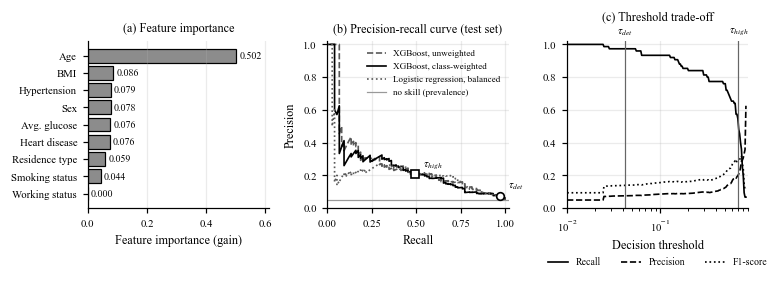

tersimpan -> ../figures-jaee/hasil_stroke.json


In [7]:
# ---------- Fig. 5: (a) kepentingan fitur, (b) kurva PR, (c) analisis ambang ----------
NAMES = {"age": "Age", "avg_glucose_level": "Avg. glucose", "bmi": "BMI", "hypertension": "Hypertension",
         "heart_disease": "Heart disease", "is_working": "Working status", "gender": "Sex",
         "residence_type": "Residence type", "smoking_status": "Smoking status"}
imp = pd.Series(art["model"].feature_importances_, index=FEATURE_ORDER).sort_values()

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(PAGE_W, 2.75))
a1.barh([NAMES[k] for k in imp.index], imp.values, color="0.55", edgecolor="black", lw=.8)
for yy, v in enumerate(imp.values): a1.text(v + .01, yy, f"{v:.3f}", va="center", fontsize=6.5)
a1.set_xlim(0, imp.max() * 1.22); a1.set_xlabel("Feature importance (gain)"); a1.set_title("(a) Feature importance")
a1.grid(axis="y", alpha=0)

styles = {"XGBoost, class-weighted (proposed)": ("-", "black"), "XGBoost, unweighted": ("--", "0.35"),
          "Logistic regression, balanced": (":", "0.35")}
for name, p in curves.items():
    pr, rc, _ = precision_recall_curve(y_te, p)
    a2.plot(rc, pr, ls=styles[name][0], color=styles[name][1], lw=1.1, label=name.replace(" (proposed)", ""))
a2.axhline(float(y_te.mean()), color="0.6", lw=.8, label="no skill (prevalence)")
for key, mk, lab in [("tau_det", "o", r"$\tau_{det}$"), ("tau_high", "s", r"$\tau_{high}$")]:
    o = ops[key]; a2.plot(o["recall"], o["precision"], mk, ms=5, mfc="white", mec="black", mew=1.1)
    a2.annotate(lab, (o["recall"], o["precision"]), textcoords="offset points", xytext=(5, 5), fontsize=7)
a2.set_xlabel("Recall"); a2.set_ylabel("Precision"); a2.set_title("(b) Precision-recall curve (test set)")
a2.set_xlim(0, 1.02); a2.set_ylim(0, 1.02); a2.legend(frameon=False, loc="upper right", fontsize=6)

ts = np.geomspace(0.01, 0.85, 200)          # > 0.85 nyaris tanpa prediksi positif -> presisi tidak stabil
sw = [conf(y_te, p_te, t) for t in ts]
for k, ls, lab in [("recall", "-", "Recall"), ("precision", "--", "Precision"), ("f1", ":", "F1-score")]:
    a3.plot(ts, [s[k] for s in sw], ls=ls, color="black", lw=1.1, label=lab)
a3.axvline(TAU_DET, color="0.4", lw=.8); a3.axvline(TAU_HIGH, color="0.4", lw=.8)
for tau, nm in [(TAU_DET, r"$\tau_{det}$"), (TAU_HIGH, r"$\tau_{high}$")]:
    a3.text(tau, 1.02, nm, transform=a3.get_xaxis_transform(), ha="center", va="bottom", fontsize=7)
a3.set_xscale("log"); a3.set_xlim(0.01, 0.9); a3.set_xlabel("Decision threshold"); a3.set_ylim(0, 1.02)
a3.set_title("(c) Threshold trade-off", pad=14)
a3.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.24), fontsize=6.5, ncol=3)
fig.tight_layout()
save(fig, "fig5_klasifikasi_stroke")
plt.show()

res = dict(dataset=desc, boot=boot, operating_points=ops, tiers=tiers, auc=auc, ap=ap, comparison=comp, sensitivity=sens,
           importance={k: float(v) for k, v in zip(FEATURE_ORDER, art["model"].feature_importances_)},
           sensitivity_inputs=dict(sigma_glucose=SIG_G, p_flip=P_FLIP, n_rep=N_REP))
json.dump(res, open(FIG / "hasil_stroke.json", "w"), indent=2, default=J)
print("tersimpan ->", FIG / "hasil_stroke.json")